# RevRate - Predykcja cen samochodow

EDA i pelny pipeline: preprocessing, trening, ewaluacja

## Importy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)

## Analiza danych

In [2]:
df = pd.read_csv('../data/Car_sale_ads.csv')
print("Opis kolumn:\n")
df.info()
print("\n\nOpis statystyczny danych:\n")
df.describe()

Opis kolumn:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208304 entries, 0 to 208303
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Index                    208304 non-null  int64  
 1   Price                    208304 non-null  int64  
 2   Currency                 208304 non-null  object 
 3   Condition                208304 non-null  object 
 4   Vehicle_brand            208304 non-null  object 
 5   Vehicle_model            208304 non-null  object 
 6   Vehicle_version          138082 non-null  object 
 7   Vehicle_generation       147860 non-null  object 
 8   Production_year          208304 non-null  int64  
 9   Mileage_km               207321 non-null  float64
 10  Power_HP                 207661 non-null  float64
 11  Displacement_cm3         206338 non-null  float64
 12  Fuel_type                208304 non-null  object 
 13  CO2_emissions            94047 non-null   flo

,Index,Price,Production_year,Mileage_km,Power_HP,Displacement_cm3,CO2_emissions,Doors_number
count,208304.000000,2.083040e+05,208304.000000,2.073210e+05,207661.000000,206338.000000,9.404700e+04,206817.000000
mean,104151.500000,6.305383e+04,2012.098241,1.502768e+05,151.836281,1882.567147,3.191564e+05,4.637138
std,60132.329574,8.665967e+04,6.998414,2.937447e+06,77.683546,729.609660,7.291396e+07,0.768559
min,0.000000,5.000000e+02,1915.000000,1.000000e+00,1.000000,400.000000,1.000000e+00,1.000000
25%,52075.750000,1.780000e+04,2008.000000,5.300000e+04,105.000000,1461.000000,1.200000e+02,5.000000
50%,104151.500000,3.570000e+04,2013.000000,1.445660e+05,136.000000,1798.000000,1.400000e+02,5.000000
75%,156227.250000,7.599000e+04,2017.000000,2.060000e+05,172.000000,1997.000000,1.640000e+02,5.000000
max,208303.000000,6.999000e+06,2021.000000,1.111111e+09,1398.000000,8400.000000,2.000000e+10,55.000000


In [3]:
def suggest_action(missing_pct, unique_count, total_rows):
    if unique_count <= 1:
        return 'USUN (brak wariancji)'
    if unique_count >= total_rows * 0.95:
        return 'USUN (ID-like)'
    if missing_pct > 50:
        return 'USUN (>50% brakow)'
    if missing_pct > 30:
        return 'ROZWAZ'
    return 'IMPUTUJ'

summary = pd.DataFrame({
    'braki': df.isnull().sum(),
    '%': (df.isnull().sum() / len(df) * 100).round(1),
    'unikalne': df.nunique(),
})
total = len(df)
summary['Sugestia'] = [
    suggest_action(row['%'], row['unikalne'], total)
    for _, row in summary.iterrows()
]
print(summary.sort_values('braki', ascending=False))

                          braki     %  unikalne               Sugestia
First_owner              143210  68.8         1  USUN (brak wariancji)
First_registration_date  121859  58.5      8441     USUN (>50% brakow)
CO2_emissions            114257  54.9       372     USUN (>50% brakow)
Origin_country            89992  43.2        37                 ROZWAZ
Vehicle_version           70222  33.7     19056                 ROZWAZ
Vehicle_generation        60444  29.0       569                IMPUTUJ
Drive                     15076   7.2         5                IMPUTUJ
Displacement_cm3           1966   0.9      1181                IMPUTUJ
Doors_number               1487   0.7        10                IMPUTUJ
Mileage_km                  983   0.5     52007                IMPUTUJ
Power_HP                    643   0.3       573                IMPUTUJ
Transmission                479   0.2         2                IMPUTUJ
Index                         0   0.0    208304         USUN (ID-like)
Offer_

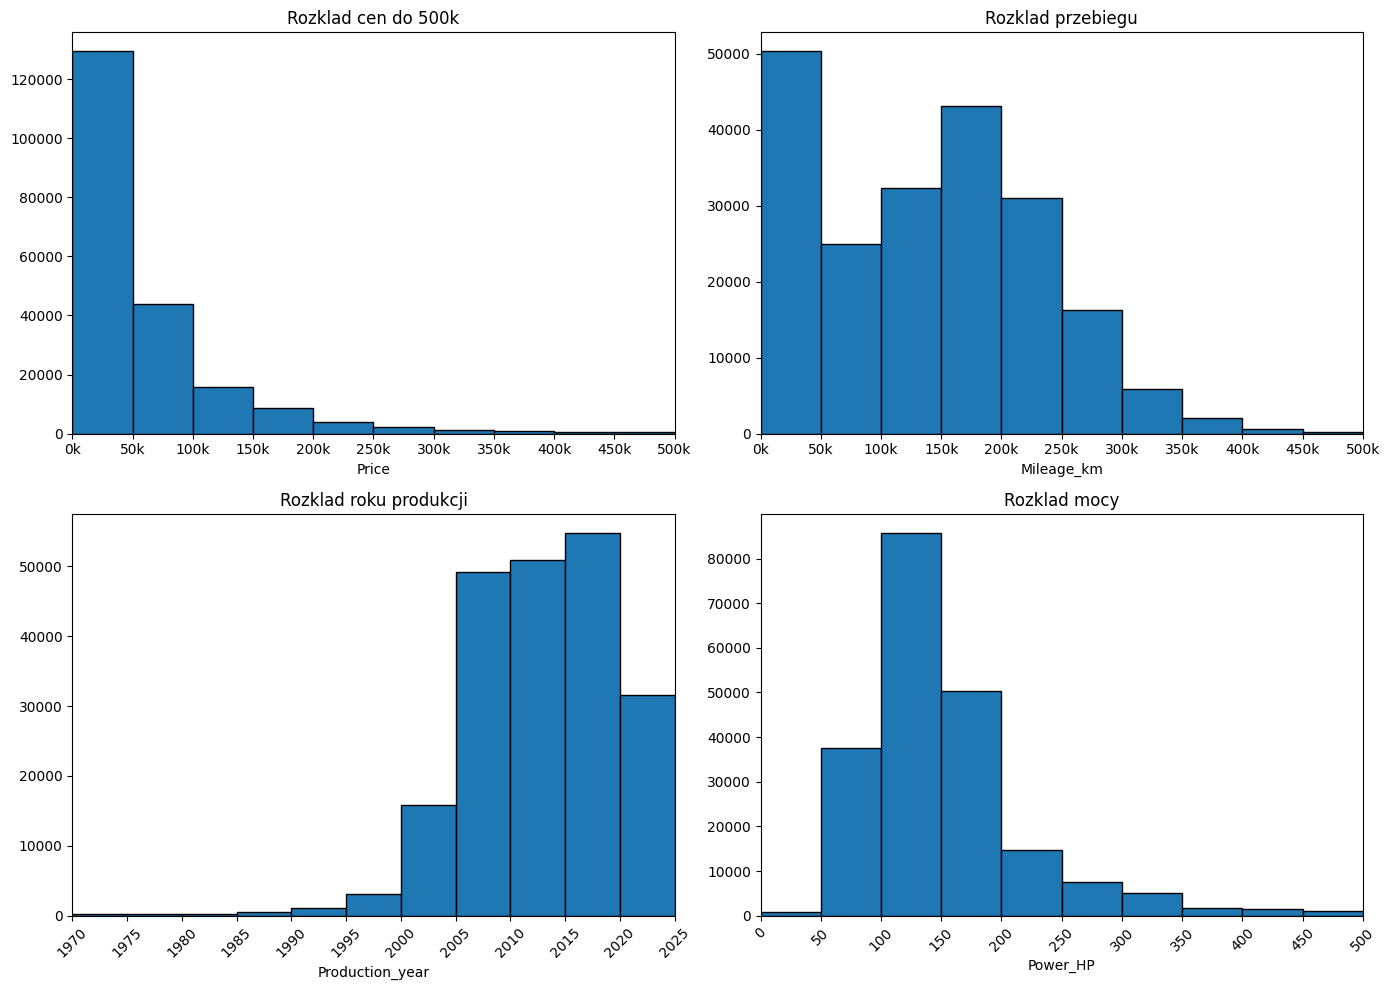

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].hist(df['Price'].dropna(), bins=10, range=(0, 500000), edgecolor='black')
axes[0,0].set_xlim(0, 500000)
axes[0,0].set_xticks(range(0, 500001, 50000))
axes[0,0].set_xticklabels([str(int(t/1000)) + 'k' for t in range(0, 500001, 50000)])
axes[0,0].set_title('Rozklad cen do 500k')
axes[0,0].set_xlabel('Price')

axes[0,1].hist(df['Mileage_km'].dropna(), bins=10, range=(0, 500000), edgecolor='black')
axes[0,1].set_xlim(0, 500000)
axes[0,1].set_xticks(range(0, 500001, 50000))
axes[0,1].set_xticklabels([str(int(t/1000)) + 'k' for t in range(0, 500001, 50000)])
axes[0,1].set_title('Rozklad przebiegu')
axes[0,1].set_xlabel('Mileage_km')

axes[1,0].hist(df['Production_year'].dropna(), bins=11, range=(1970, 2025), edgecolor='black')
axes[1,0].set_xlim(1970, 2025)
axes[1,0].set_xticks(range(1970, 2026, 5))
axes[1,0].set_xticklabels([str(t) for t in range(1970, 2026, 5)], rotation=45)
axes[1,0].set_title('Rozklad roku produkcji')
axes[1,0].set_xlabel('Production_year')

axes[1,1].hist(df['Power_HP'].dropna(), bins=10, range=(0, 500), edgecolor='black')
axes[1,1].set_xlim(0, 500)
axes[1,1].set_xticks(range(0, 501, 50))
axes[1,1].set_xticklabels([str(t) for t in range(0, 501, 50)], rotation=45)
axes[1,1].set_title('Rozklad mocy')
axes[1,1].set_xlabel('Power_HP')

plt.tight_layout()
plt.show()

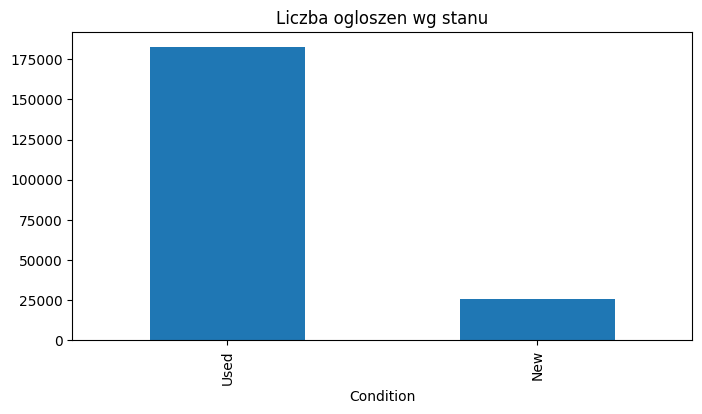

In [5]:
df['Condition'].value_counts().plot(kind='bar', figsize=(8,4), title='Liczba ogloszen wg stanu')
plt.show()

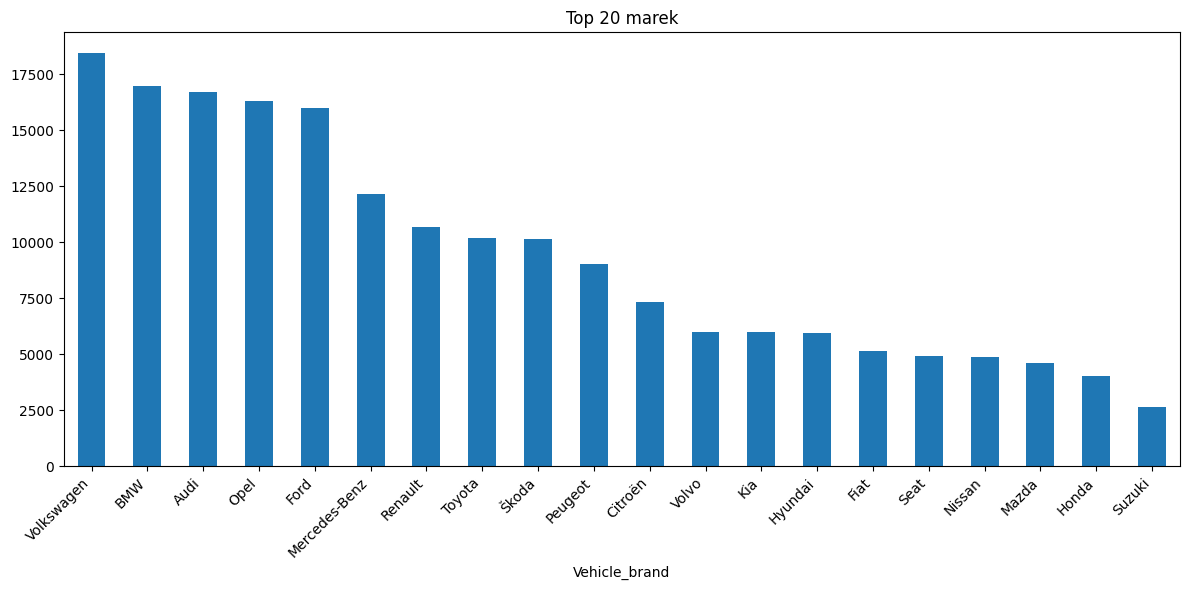

In [6]:
top_brands = df['Vehicle_brand'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(12,6))
top_brands.plot(kind='bar', ax=ax)
ax.set_title('Top 20 marek')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

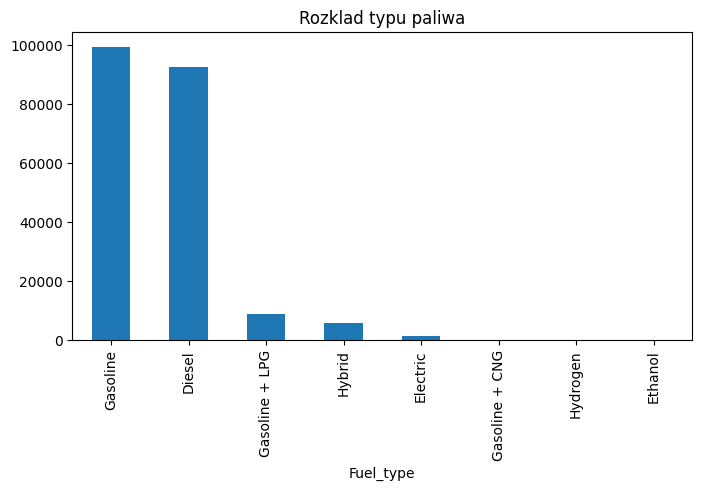

In [7]:
df['Fuel_type'].value_counts().plot(kind='bar', figsize=(8,4), title='Rozklad typu paliwa')
plt.show()

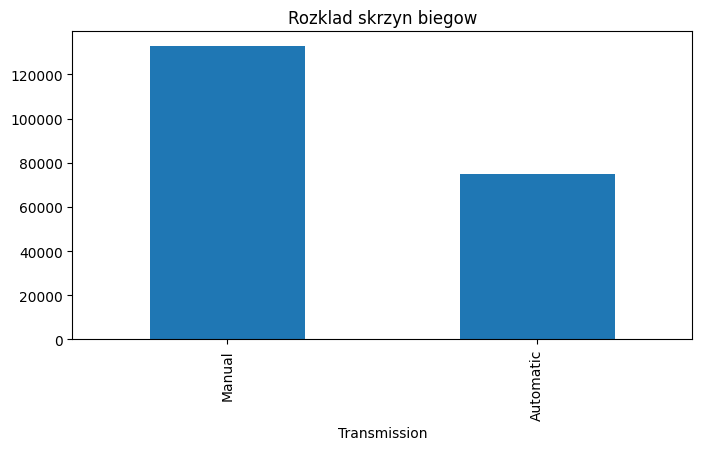

In [8]:
df['Transmission'].value_counts().plot(kind='bar', figsize=(8,4), title='Rozklad skrzyn biegow')
plt.show()

In [9]:
df['Currency'].value_counts()

Currency
PLN    208034
EUR       270
Name: count, dtype: int64

In [10]:
corr_cols = df.select_dtypes(include=[np.number]).columns
corr = df[corr_cols].corr()['Price'].sort_values(ascending=False)
print('Korelacja z cena:')
print(corr)

Korelacja z cena:
Price               1.000000
Power_HP            0.641298
Production_year     0.441425
Displacement_cm3    0.362415
CO2_emissions      -0.001300
Mileage_km         -0.017602
Doors_number       -0.034275
Index              -0.106673
Name: Price, dtype: float64


## Czyszczenie danych

In [11]:
df_cleaned = df.copy()

eur_mask = df_cleaned['Currency'] == 'EUR'
df_cleaned.loc[eur_mask, 'Price'] = (df_cleaned.loc[eur_mask, 'Price'] * 4.30).round().astype(int)

df_cleaned['Price'] = pd.to_numeric(df_cleaned['Price'], errors='coerce')
df_cleaned = df_cleaned[df_cleaned['Price'] > 0].reset_index(drop=True)

Q1 = df_cleaned['Price'].quantile(0.25)
Q3 = df_cleaned['Price'].quantile(0.75)
IQR = Q3 - Q1
df_cleaned = df_cleaned[(df_cleaned['Price'] >= Q1 - 1.5 * IQR) & (df_cleaned['Price'] <= Q3 + 1.5 * IQR)].reset_index(drop=True)

df_cleaned['Production_year'] = pd.to_numeric(df_cleaned['Production_year'], errors='coerce')
df_cleaned = df_cleaned[df_cleaned['Production_year'] >= 1990].reset_index(drop=True)

df_cleaned['Mileage_km'] = pd.to_numeric(df_cleaned['Mileage_km'], errors='coerce')
df_cleaned = df_cleaned[~(df_cleaned['Mileage_km'] < 0)].reset_index(drop=True)
df_cleaned.loc[df_cleaned['Mileage_km'] > 450000, 'Mileage_km'] = 450000
df_cleaned['_age'] = df_cleaned['Production_year'].max() - df_cleaned['Production_year']
used_zero = (df_cleaned['Condition'] == 'Used') & (df_cleaned['Mileage_km'] == 0)
model_age_mean = (
    df_cleaned[df_cleaned['Mileage_km'] > 0]
    .groupby(['Vehicle_model', '_age'])['Mileage_km']
    .mean()
)
idx = pd.MultiIndex.from_frame(df_cleaned.loc[used_zero, ['Vehicle_model', '_age']])
df_cleaned.loc[used_zero, 'Mileage_km'] = idx.map(model_age_mean)
df_cleaned = df_cleaned.drop(columns=['_age'])

df_cleaned['Power_HP'] = pd.to_numeric(df_cleaned['Power_HP'], errors='coerce')
df_cleaned.loc[df_cleaned['Power_HP'] > 800, 'Power_HP'] = 800

df_cleaned['Displacement_cm3'] = pd.to_numeric(df_cleaned['Displacement_cm3'], errors='coerce')

keep_fuel = ['Gasoline', 'Diesel', 'Gasoline + LPG']
df_cleaned = df_cleaned[df_cleaned['Fuel_type'].isin(keep_fuel)].reset_index(drop=True)

df_cleaned['CO2_emissions'] = pd.to_numeric(df_cleaned['CO2_emissions'], errors='coerce')
for ft in keep_fuel:
    mask = df_cleaned['Fuel_type'] == ft
    if mask.sum() > 0:
        cap = df_cleaned.loc[mask, 'CO2_emissions'].quantile(0.99)
        if not pd.isna(cap):
            df_cleaned.loc[mask & (df_cleaned['CO2_emissions'] > cap), 'CO2_emissions'] = cap

df_cleaned['Doors_number'] = pd.to_numeric(df_cleaned['Doors_number'], errors='coerce')
df_cleaned['Doors_number'] = df_cleaned['Doors_number'].clip(2, 5)

df_cleaned = df_cleaned.drop(columns=[
    'Index', 'Currency', 'Offer_location',
    'Vehicle_version', 'Vehicle_generation',
    'First_registration_date', 'First_owner',
    'Features', 'Origin_country', 'CO2_emissions'
])

print('Po czyszczeniu:', df_cleaned.shape)

Po czyszczeniu: (184876, 15)


## Imputacja brakow

In [ ]:
def find_similar_cars(pool, core_cols, core_vals, opt_cols, opt_vals):
    cand = pool
    for c, v in zip(core_cols, core_vals):
        cand = cand[cand[c] == v]
    opt_present = [c for c, v in zip(opt_cols, opt_vals) if not pd.isna(v)]
    if opt_present:
        cand_opt = cand
        for c, v in zip(opt_cols, opt_vals):
            if not pd.isna(v):
                cand_opt = cand_opt[cand_opt[c] == v]
        if len(cand_opt) > 0:
            cand = cand_opt
    return cand

def pick_value(cand, col):
    if pd.api.types.is_numeric_dtype(cand[col]):
        return cand[col].median()
    mode_vals = cand[col].mode()
    return mode_vals[0] if not mode_vals.empty else cand.iloc[0][col]

def impute_by_fingerprint(df, target_cols, core_cols, opt_cols):
    n_core = len(core_cols)
    records = []
    for col in target_cols:
        missing = df[df[col].isna()]
        if missing.empty:
            continue
        pool = df[df[col].notna()]
        for key, group in missing.groupby(core_cols + opt_cols, dropna=False):
            core_vals = key[:n_core]
            if any(pd.isna(v) for v in core_vals):
                continue
            opt_vals = key[n_core:]
            cand = find_similar_cars(pool, core_cols, core_vals, opt_cols, opt_vals)
            if len(cand) == 0:
                continue
            opt_present = [c for c, v in zip(opt_cols, opt_vals) if not pd.isna(v)]
            val = pick_value(cand, col)
            for idx in group.index:
                df.loc[idx, col] = val
                records.append({
                    'missing_row': idx,
                    'column': col,
                    'matched_row': cand.index[0],
                    'value': val,
                    'fingerprint_core': str(core_vals),
                    'fingerprint_opt': ','.join(opt_present),
                })
    return records

df_imputed = df_cleaned.copy()

core_cols = ['Vehicle_brand', 'Vehicle_model', 'Production_year', 'Type', 'Fuel_type']
opt_cols = ['Transmission', 'Power_HP', 'Doors_number', 'Displacement_cm3']
target_cols = ['Transmission', 'Doors_number', 'Power_HP', 'Displacement_cm3', 'Drive']

matches = []

for pass_num in range(2):
    pass_start = len(matches)
    matches += impute_by_fingerprint(df_imputed, target_cols, core_cols, opt_cols)
    print(f'Pass {pass_num + 1} fingerprint: {len(matches) - pass_start}')

num_cols = df_imputed.select_dtypes(include=[np.number]).columns
cat_cols = df_imputed.select_dtypes(include=['object']).columns

df_imputed[num_cols] = SimpleImputer(strategy='median').fit_transform(df_imputed[num_cols])
df_imputed[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(df_imputed[cat_cols])

pd.DataFrame(matches).to_csv('../data/imputation_matches.csv', index=False)



print('Po imputacji:', df_imputed.shape)

KeyError: 'CO2_emissions'

In [ ]:
summary = pd.DataFrame({
    'braki': df_imputed.isnull().sum(),
    '%': (df_imputed.isnull().sum() / len(df_imputed) * 100).round(1),
})
print(summary.sort_values('braki', ascending=False))
assert df_imputed.isnull().sum().sum() == 0

## Inżynieria cech

In [ ]:
df_features = df_imputed.copy()

pub_dates = pd.to_datetime(df_features['Offer_publication_date'], errors='coerce')
pub_years = pub_dates.dt.year.fillna(pd.Timestamp.now().year).astype(int)

df_features['car_age'] = (pub_years - df_features['Production_year']).clip(lower=0)
df_features.drop(columns=['Production_year', 'Offer_publication_date'], inplace=True)

df_features['mileage_per_year'] = df_features['Mileage_km'] / df_features['car_age'].clip(lower=1)
df_features['power_to_displacement'] = np.where(
    df_features['Displacement_cm3'] > 0,
    df_features['Power_HP'] / df_features['Displacement_cm3'],
    0,
)
print('Ksztalt po ekstrakcji:', df_features.shape)

## Selekcja cech

In [ ]:
n_top = 15
threshold = 0.01

X_feat = df_features.drop(columns=['Price']).copy()
for col in X_feat.select_dtypes(include=['object']).columns:
    X_feat[col] = X_feat[col].astype('category').cat.codes
y_feat = df_features['Price']

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_feat, y_feat)

importances = (
    pd.DataFrame({'feature': X_feat.columns, 'importance': rf.feature_importances_})
    .sort_values('importance', ascending=False)
)

selected = importances[(importances['importance'] >= threshold) | (importances.reset_index().index < n_top)]
selected_features = selected['feature'].tolist()

print(f'Wybrano {len(selected_features)} cech z {len(X_feat.columns)} dostepnych')

importances.head(20).plot.barh(x='feature', y='importance', figsize=(8, 6))
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Preprocessing danych

In [ ]:
available_features = [f for f in selected_features if f in df_features.columns]
X = df_features[available_features].copy()
y = df_features['Price'].values

for col in X.select_dtypes(include=['object']).columns:
    converted = pd.to_numeric(X[col], errors='coerce')
    if converted.notna().all():
        X[col] = converted

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

n_num = len(numeric_features)
n_cat = len(categorical_features)
print(f'Model używa {len(available_features)} cech (numeryczne: {n_num}, kategoryczne: {n_cat}):\n')

if numeric_features:
    print(f'Numeryczne ({n_num}):')
    for f in numeric_features:
        print(f'  - {f}')

if categorical_features:
    print(f'\nKategoryczne ({n_cat}):')
    for f in categorical_features:
        print(f'  - {f}')


numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False,
        max_categories=20,
        min_frequency=0.001,
    )),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    remainder='drop',
)

print('Preprocessor zdefiniowany')

## Split zbioru na Train i Test

In [ ]:
bins = pd.qcut(y, q=10, labels=False, duplicates='drop')
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=bins
)

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

print('Train:', X_train.shape, 'Test:', X_test.shape)

## Trening modelu

In [ ]:
param_grid = {
    'n_estimators': [300, 400],
    'max_depth': [12, 16, 20],
    'min_samples_leaf': [5, 10, 20],
    'max_features': ['sqrt', 0.5],
}

base_rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=base_rf,
    param_grid=param_grid,
    cv = KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print('Najlepsze parametry:', grid_search.best_params_)
print('Najlepszy CV score (negRMSE):', grid_search.best_score_)

## Ewaluacja modelu

In [ ]:
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f'Train  RMSE={train_rmse:.2f}  MAE={train_mae:.2f}  R2={train_r2:.4f}')
print(f'Test   RMSE={test_rmse:.2f}  MAE={test_mae:.2f}  R2={test_r2:.4f}')

## Zapis modelu, preprocessora i listy cech

In [ ]:
joblib.dump(best_model, '../models/custom_model.pkl')
joblib.dump(preprocessor, '../models/custom_preprocessor.pkl')
joblib.dump(selected_features, '../models/custom_top_features.pkl')
                         
print('Model, preprocessor i lista cech zapisane joblibem')